In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T, models
from sklearn.model_selection import train_test_split
from PIL import Image
from collections import Counter
from tqdm import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import matplotlib.pyplot as plt


In [2]:
# PARAMS
BATCH_SIZE = 32
EPOCHS = 25
criterion = nn.L1Loss()
LEARNING_RATE = 0.00003

In [ ]:
def plot_training_curves(train_losses, val_losses, train_maes, val_maes, save_path = './plots/learning_curve.png'):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))

    # Loss 
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o', color='#414141')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o', color='#8FA31E')
    plt.title('Loss por Época', fontsize=14)
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # MAE 
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_maes, label='Train MAE', marker='o', color='#414141')
    plt.plot(epochs, val_maes, label='Validation MAE', marker='o', color='#8FA31E')
    plt.title('MAE por Época', fontsize=14)
    plt.xlabel('Época')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig(save_path, dpi = 150)


In [4]:
df = pd.read_parquet('./UTKFACE_dataset.parquet')
df.head()

,image_path,age,gender,race,race_decoded,gender_decoded
19,./UTKFACE/10_0_0_20161220222308131.jpg,10,0,0,White,Male
20,./UTKFACE/10_0_0_20170103200329407.jpg,10,0,0,White,Male
21,./UTKFACE/10_0_0_20170103200522151.jpg,10,0,0,White,Male
22,./UTKFACE/10_0_0_20170103233459275.jpg,10,0,0,White,Male
23,./UTKFACE/10_0_0_20170104013211746.jpg,10,0,0,White,Male


In [5]:
# Split estratificado por edad, mantenemos el desbalance todo el momento.
# Train -> 80%
# Validation -> 10%
# Test -> 10%

train_df, temp_df = train_test_split(df, test_size = 0.20, stratify = df['age'], random_state = 42)

val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify = temp_df['age'], random_state = 42)

print(f"""
Train:\t{len(train_df)}
Validation:\t{len(val_df)}
Test:\t{len(test_df)}
""")



Train:	16308
Validation:	2038
Test:	2039



In [6]:
train_transform = T.Compose([
    T.Resize((244, 244)),
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),  
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),  
    T.RandomRotation(15),  
    T.RandomApply([T.GaussianBlur(3)], p=0.2),
    T.RandomGrayscale(p=0.15),  
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((244, 244)),
    T.ToTensor(),
    T.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
])


In [ ]:
class AgeDataset(Dataset):
    
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = Image.open(row.image_path).convert("RGB")
        img = self.transform(img)

        target = torch.tensor(row.age, dtype=torch.float32)

        return img, target

    def __len__(self):
        return len(self.df)


class EfficientNetV2Regression(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.efficientnet_v2_l(weights='IMAGENET1K_V1')

        # Congelar todo excepto últimas 2 capas (features.6 y features.7)
        for name, param in self.backbone.named_parameters():
            if "features.6" not in name and "features.7" not in name:
                param.requires_grad = False
        
        # Obtener dimensión de features de entrada
        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),     
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),         
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),     
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),        
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),        
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.backbone(x).squeeze(1)
    



In [ ]:
# WeightedRandomSampler para balancear en train, es decir, para que cada epoca, el dataloader cargue de forma sampleada
counts = Counter(train_df['age'])
weights = torch.tensor([1.0 / counts[i] for i in train_df['age']], dtype=torch.float32)
sampler = WeightedRandomSampler(weights, num_samples = len(weights), replacement=True)


In [9]:
train_loader = DataLoader(
    AgeDataset(train_df, train_transform),
    batch_size = BATCH_SIZE,
    sampler = sampler,
    num_workers = 4
)

val_loader = DataLoader(
    AgeDataset(val_df, val_transform),
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 4
)

test_loader = DataLoader(
    AgeDataset(test_df, val_transform),
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 4
)


In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_mae = 0
    
    progress_bar = tqdm(loader, desc="Training", leave=False, unit='batch')
    
    for imgs, targets in progress_bar:
        imgs = imgs.to(device)
        targets = targets.to(device) 
        
        preds = model(imgs)          
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # MAE por batch
        batch_mae = torch.abs(preds - targets).mean()

        total_loss += loss.item()
        total_mae += batch_mae.item()

        progress_bar.set_postfix({"batch_loss": f"{loss.item():.4f}"})
    
    return total_loss / len(loader), total_mae / len(loader)



def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_mae = 0

    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Validating", leave=False, unit='batch'):
            imgs = imgs.to(device)
            targets = targets.to(device)

            preds = model(imgs)
            loss = criterion(preds, targets)

            mae = torch.abs(preds - targets).mean()

            total_loss += loss.item()
            total_mae += mae.item()

    return total_loss / len(loader), total_mae / len(loader)


Epoca 1/25


Train Loss: 36.8056	Train MAE: 36.8056
Val Loss: 24.8363	Val MAE: 24.8363
Learning Rate: 0.000030

Epoca 2/25


Train Loss: 24.0420	Train MAE: 24.0420
Val Loss: 13.9217	Val MAE: 13.9217
Learning Rate: 0.000030

Epoca 3/25


Train Loss: 11.0184	Train MAE: 11.0184
Val Loss: 6.6694	Val MAE: 6.6694
Learning Rate: 0.000030

Epoca 4/25


Train Loss: 8.4759	Train MAE: 8.4759
Val Loss: 5.9671	Val MAE: 5.9671
Learning Rate: 0.000030

Epoca 5/25


...

Train Loss: 5.4083	Train MAE: 5.4083
Val Loss: 5.2243	Val MAE: 5.2243
Learning Rate: 0.000030

Epoca 22/25


Train Loss: 5.3687	Train MAE: 5.3687
Val Loss: 5.1712	Val MAE: 5.1712
Learning Rate: 0.000030

Epoca 23/25


Train Loss: 5.1088	Train MAE: 5.1088
Val Loss: 5.0086	Val MAE: 5.0086
Learning Rate: 0.000030

Epoca 24/25


Train Loss: 5.1036	Train MAE: 5.1036
Val Loss: 5.3698	Val MAE: 5.3698
Learning Rate: 0.000030

Epoca 25/25


Train Loss: 5.0848	Train MAE: 5.0848
Val Loss: 5.1735	Val MAE: 5.1735
Learning Rate: 0.000030



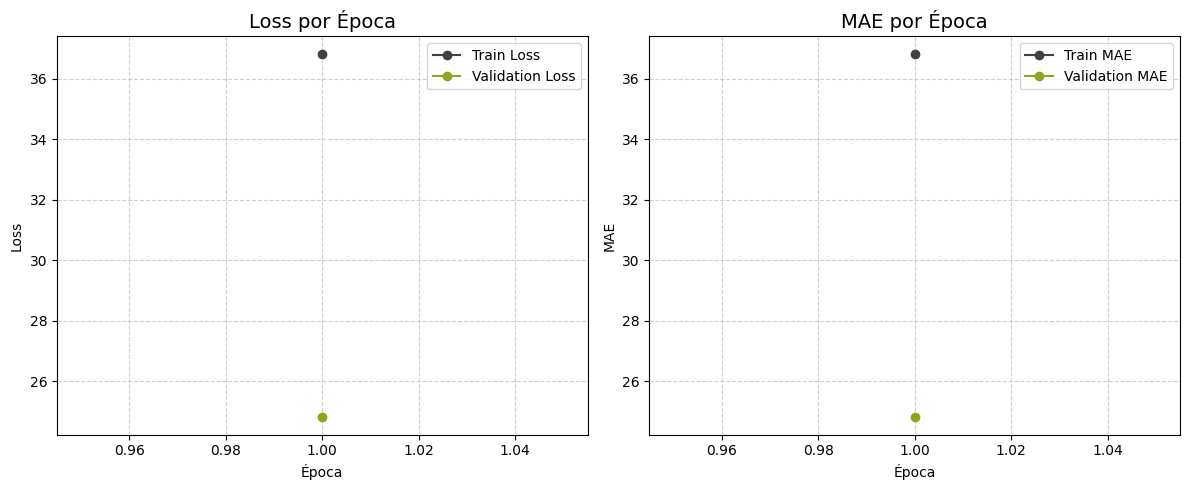

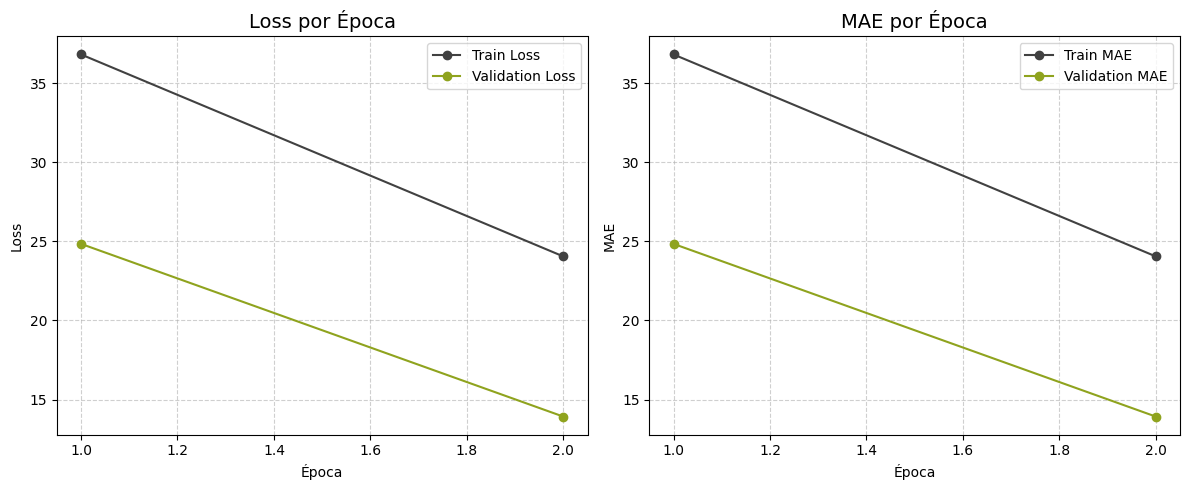

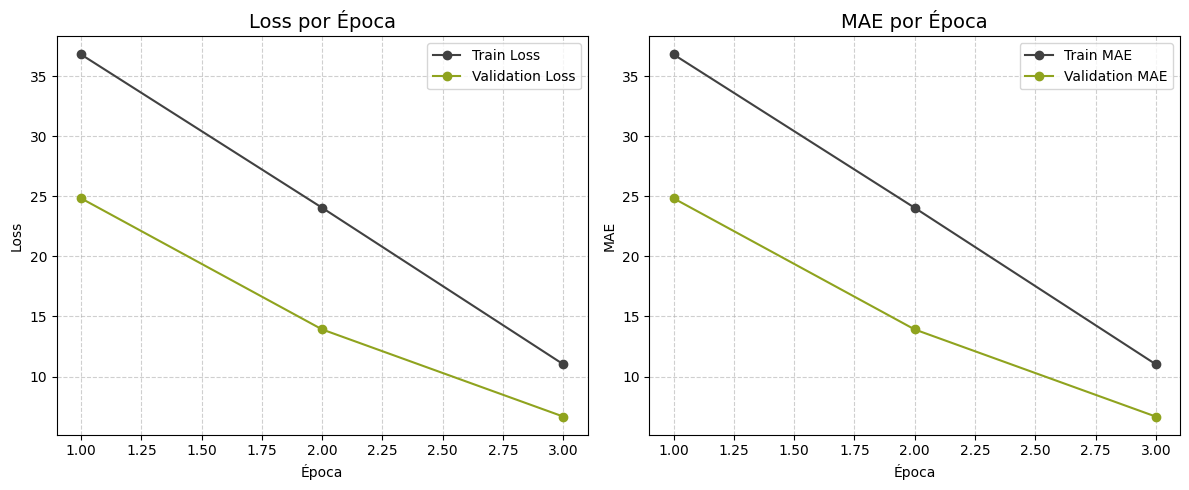

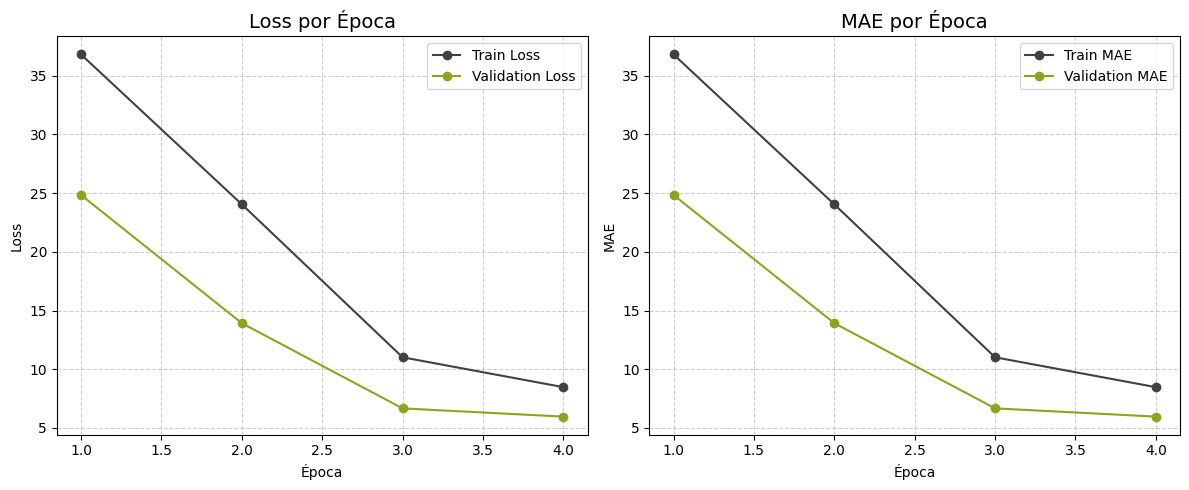

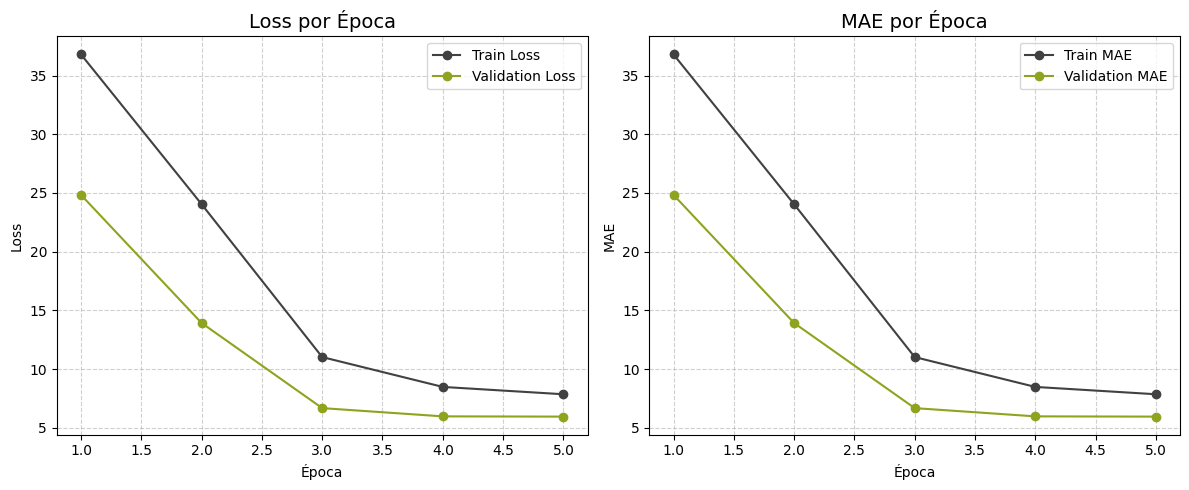

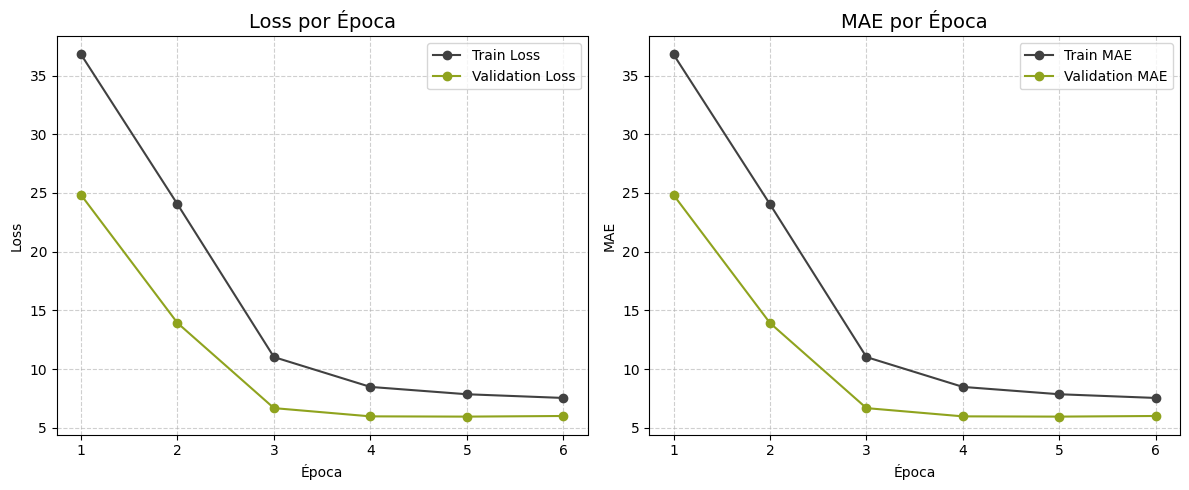

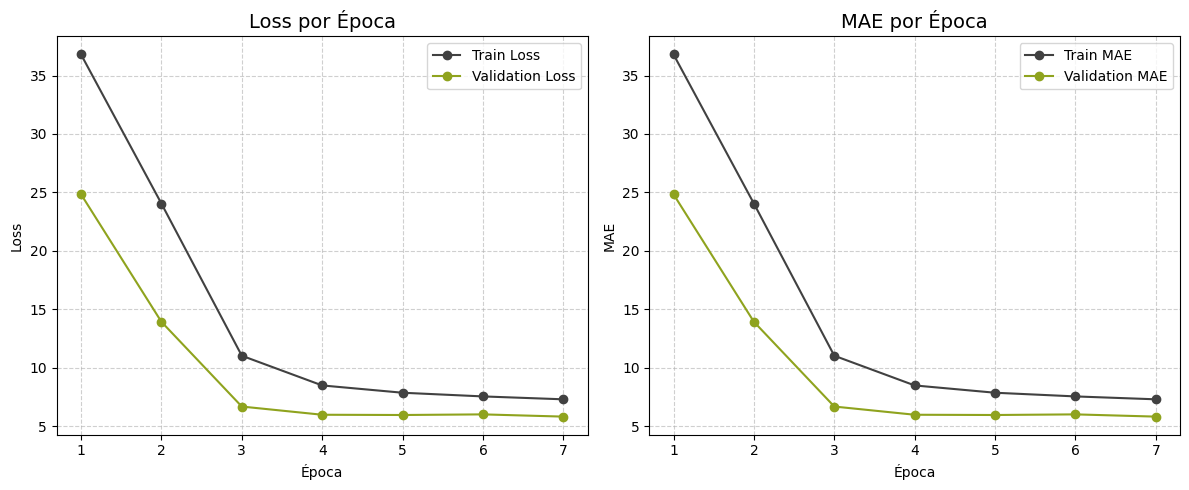

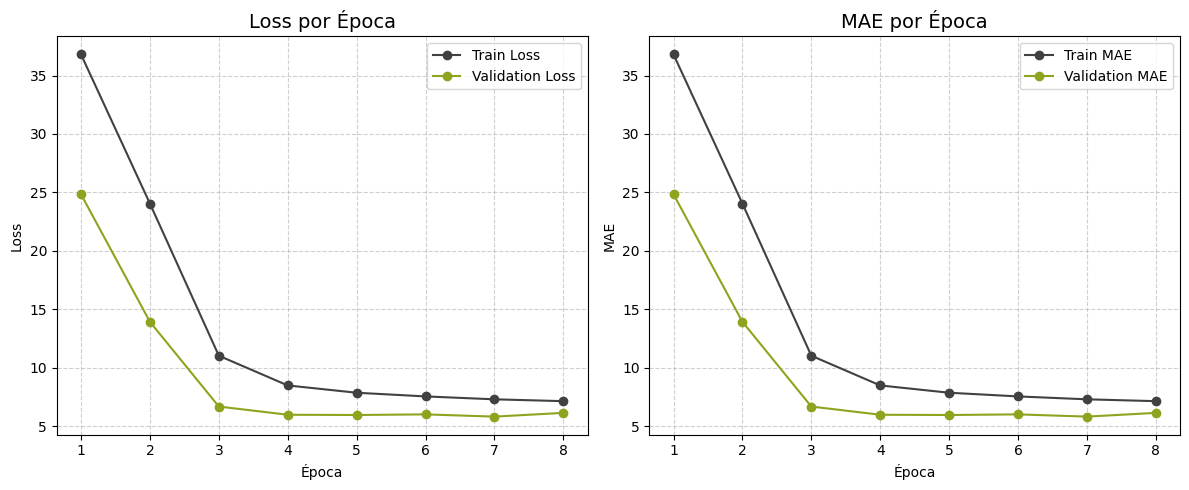

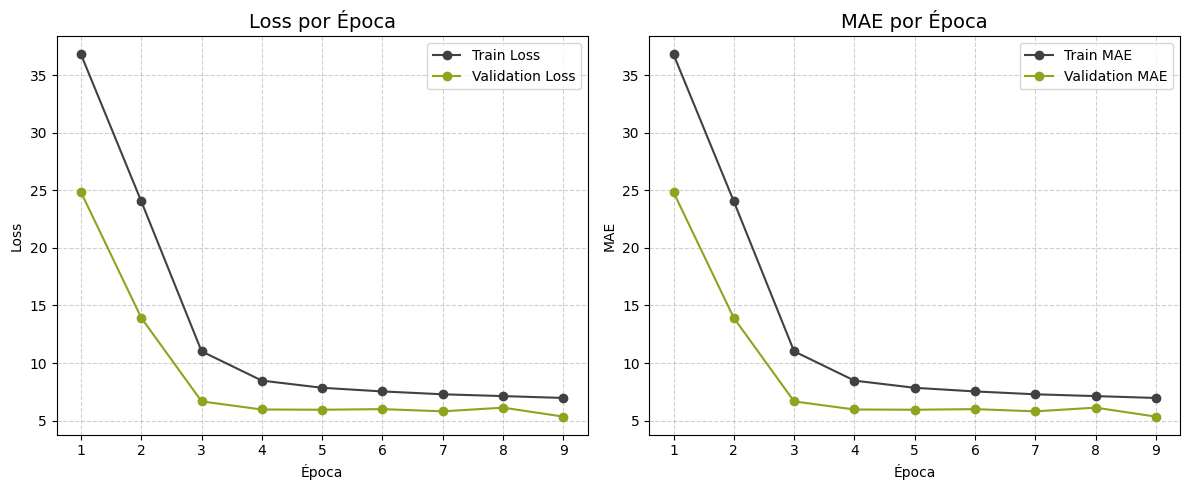

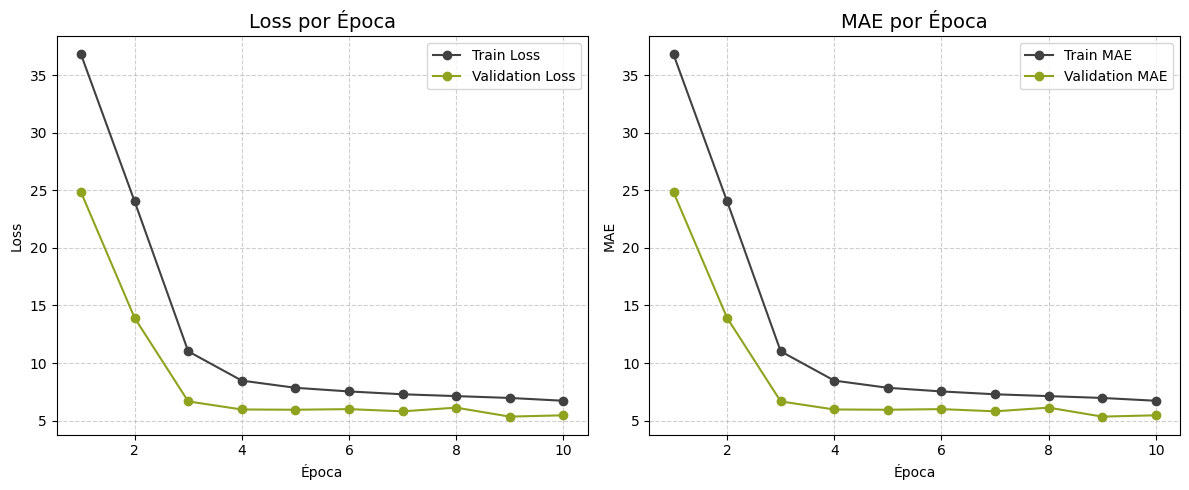

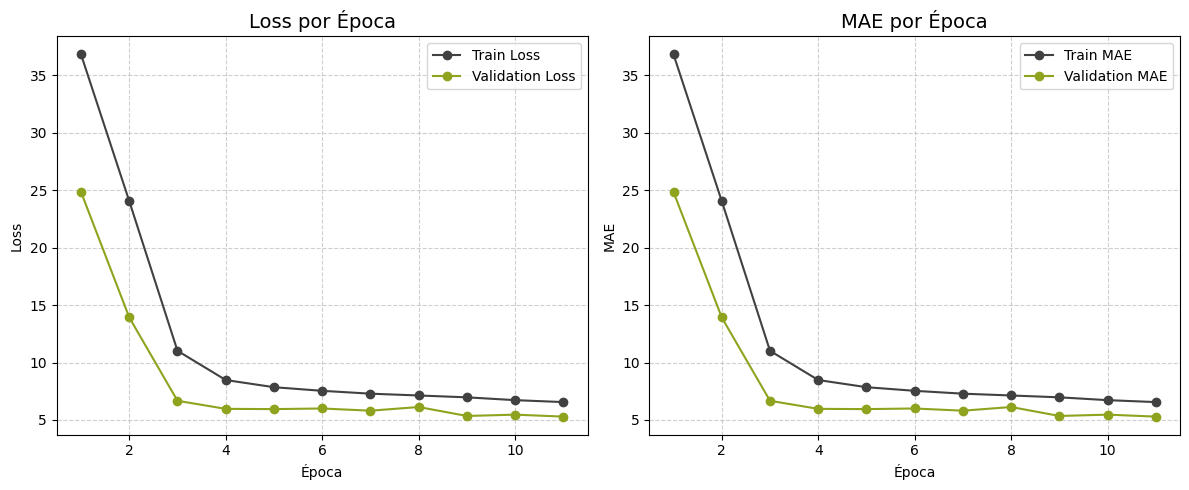

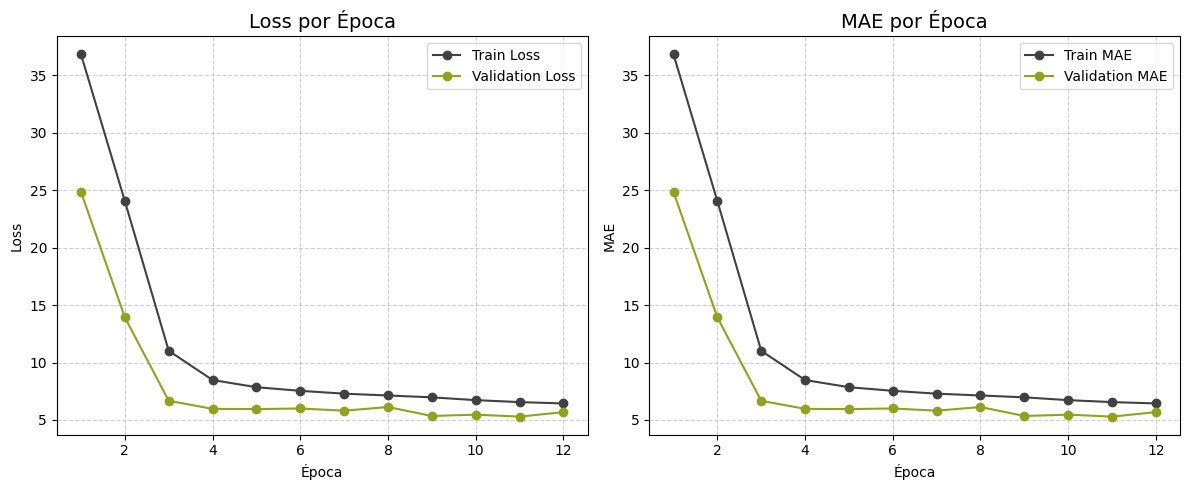

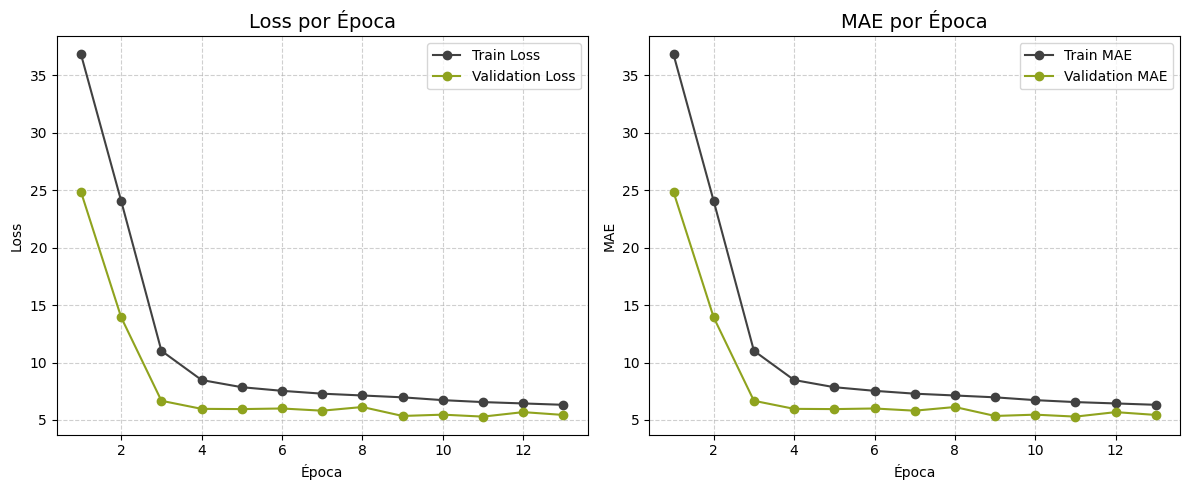

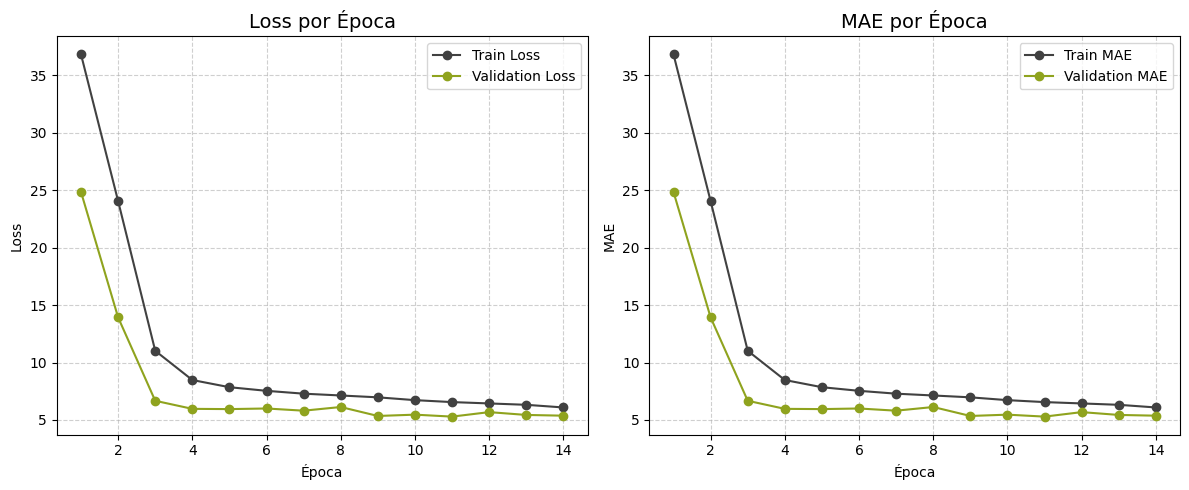

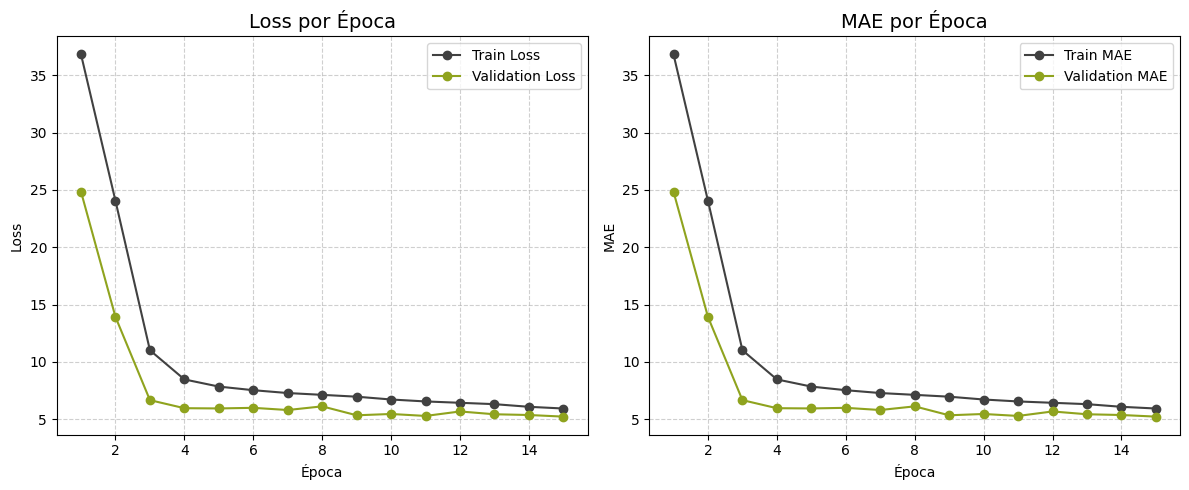

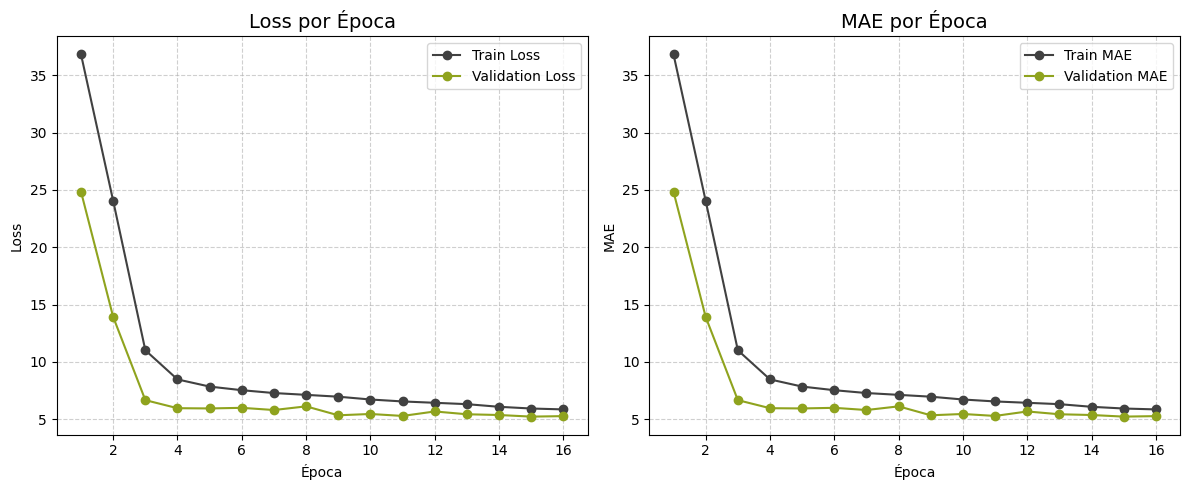

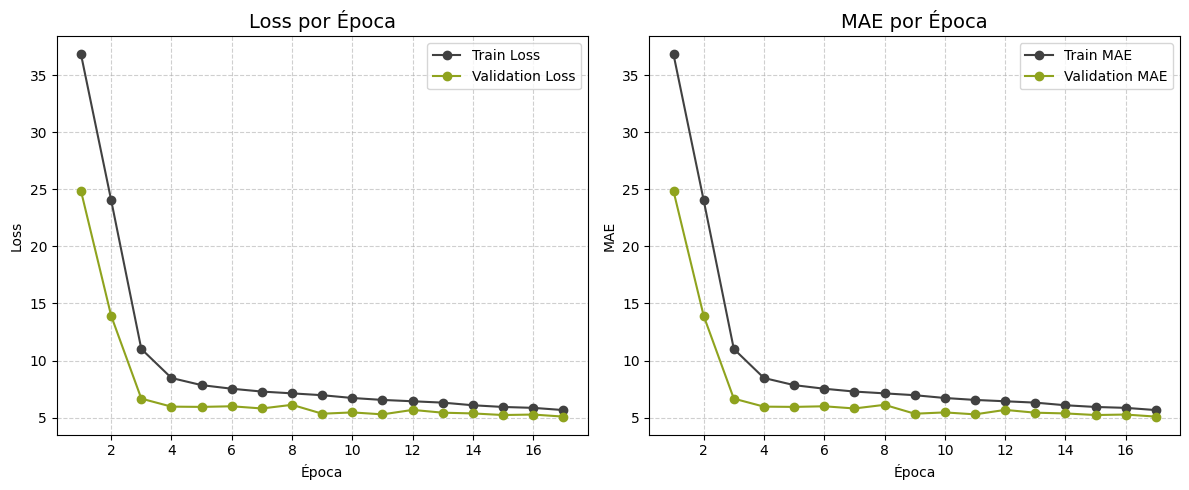

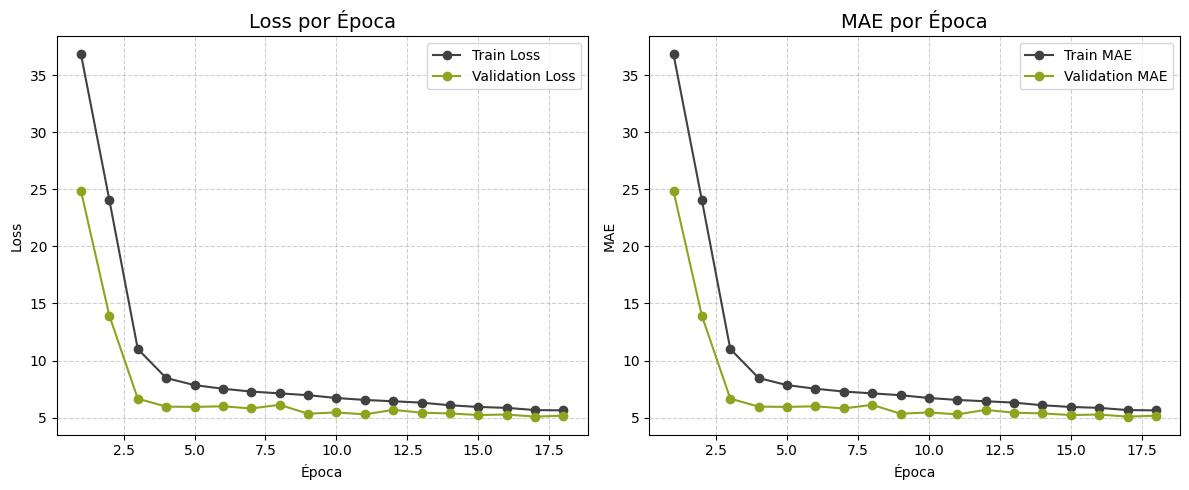

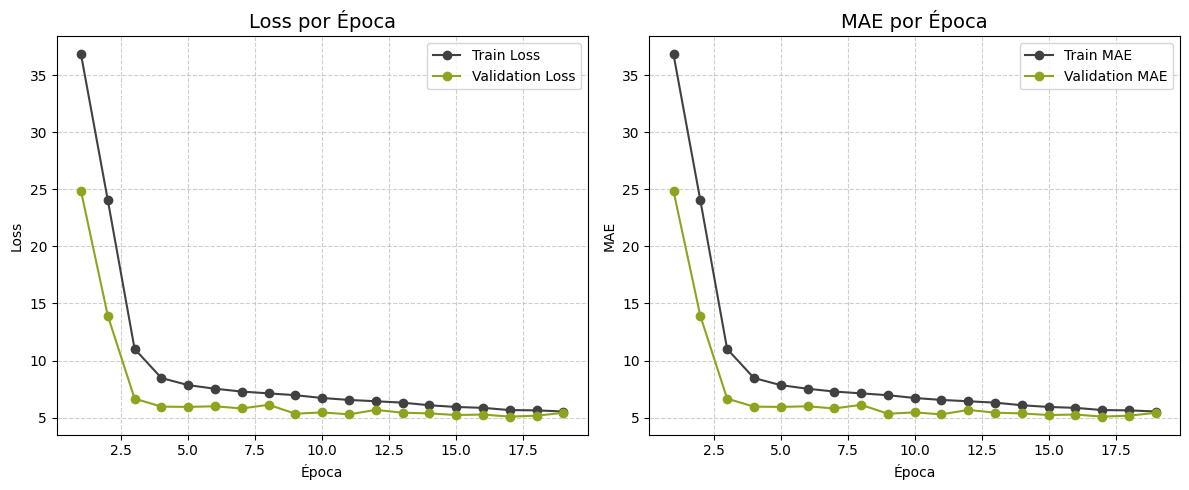

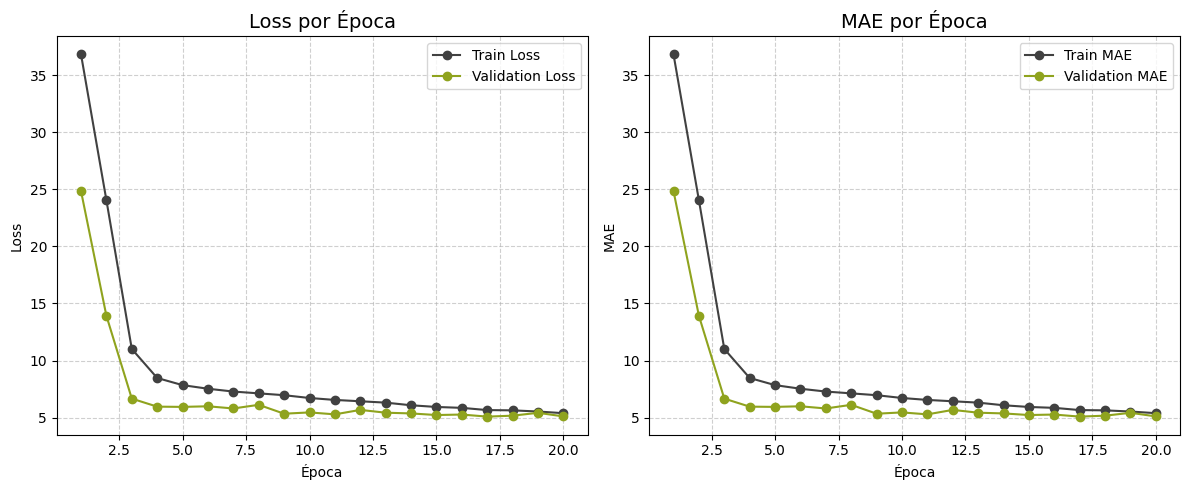

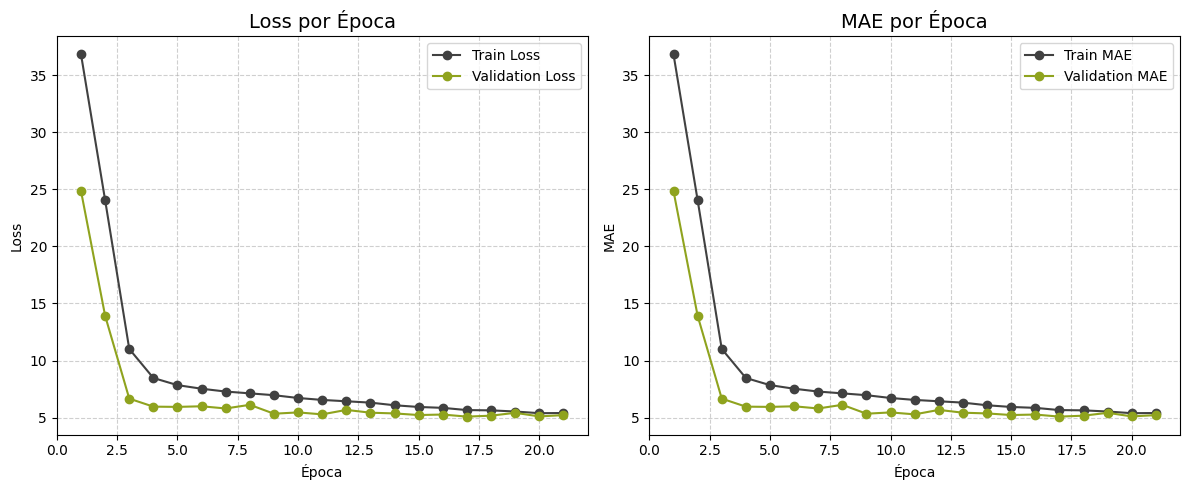

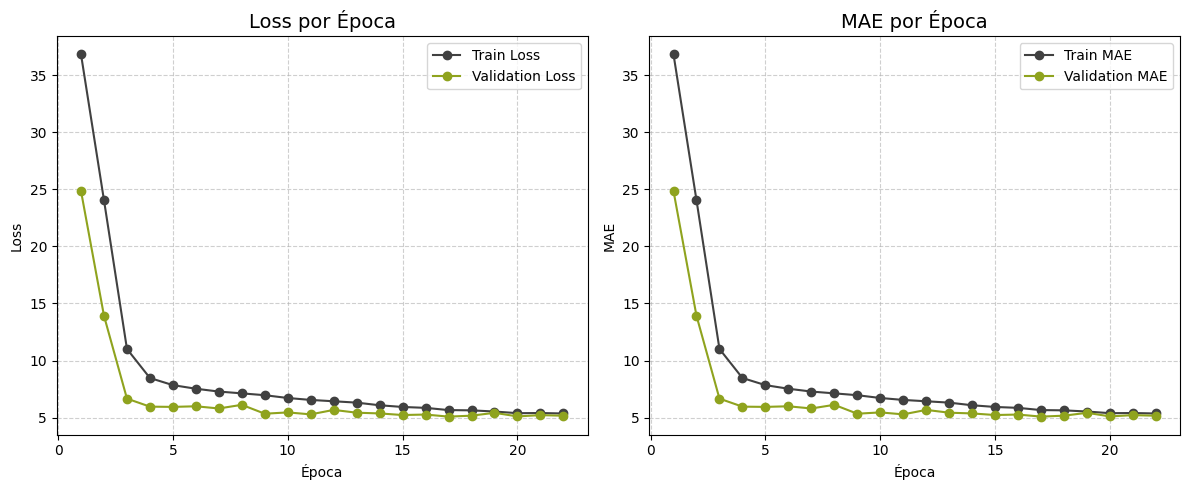

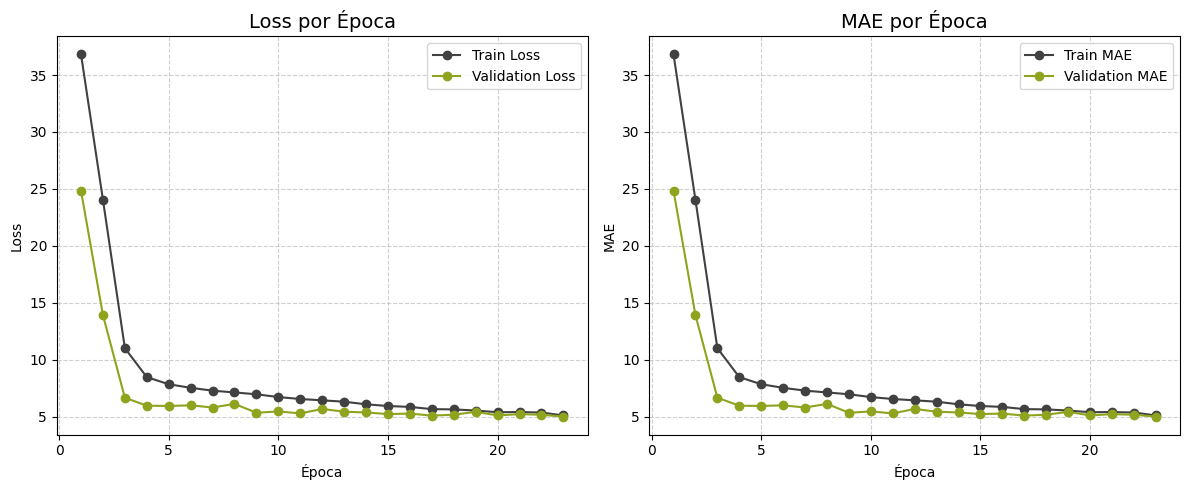

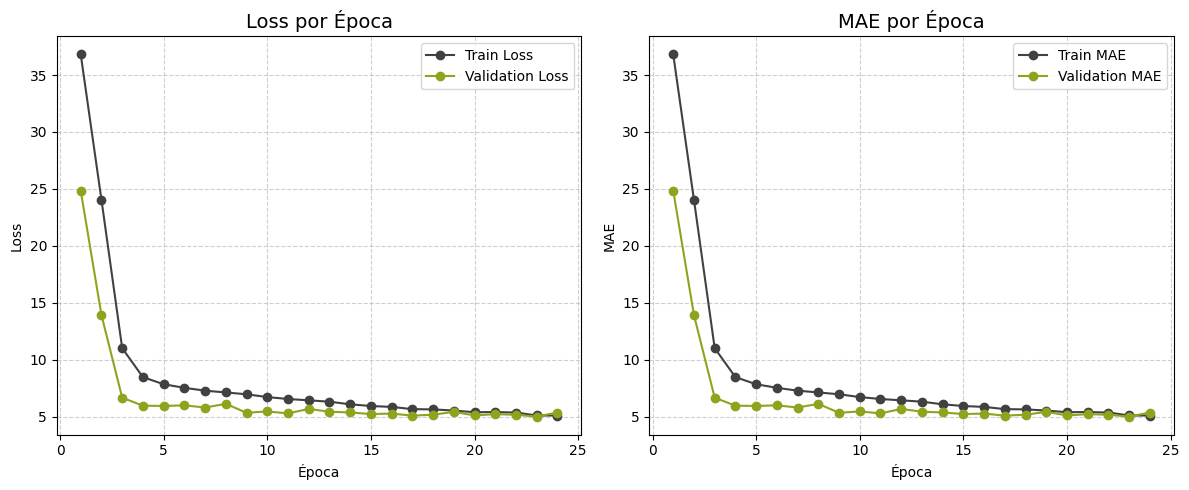

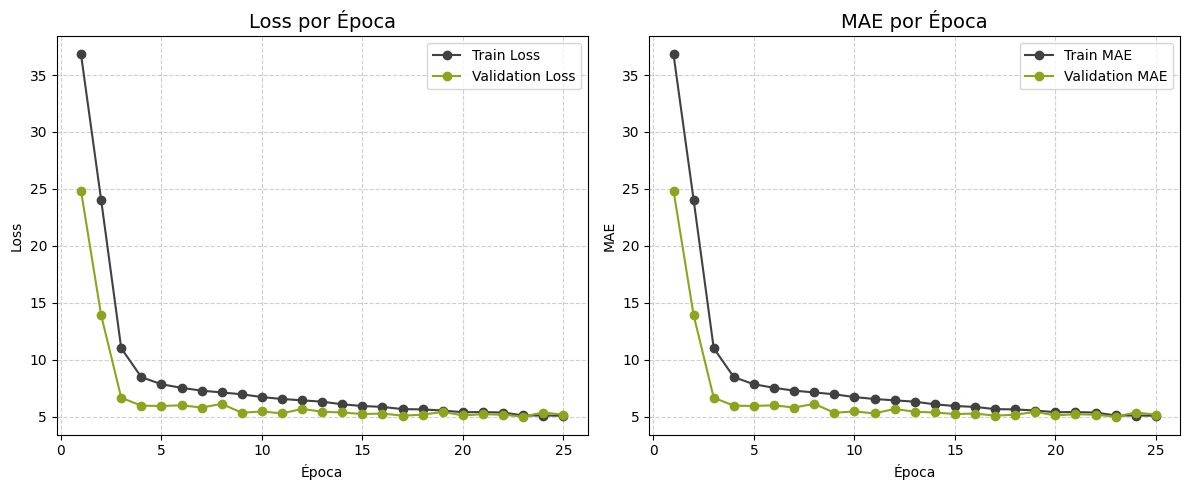

In [ ]:
device = "cuda"
model = EfficientNetV2Regression().to(device)
optimizer = AdamW(model.parameters(), lr = LEARNING_RATE, weight_decay = 0.01)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5)

train_losses = []
val_losses = []
train_maes = []
val_maes = []

for epoch in range(EPOCHS):
    print(f'Epoca {epoch+1}/{EPOCHS}')
    train_loss, train_mae = train_epoch(model, train_loader, optimizer, criterion,  device)
    val_loss, val_mae = val_epoch(model, val_loader, criterion, device)

    scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_maes.append(train_mae)
    val_maes.append(val_mae)
    


    print(f'Train Loss: {train_loss:.4f}\tTrain MAE: {train_mae:.4f}')
    print(f'Val Loss: {val_loss:.4f}\tVal MAE: {val_mae:.4f}')
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}\n")
    plot_training_curves(train_losses, val_losses, train_maes, val_maes, save_path = './plots/EfficientNetV2Regression_learning_curve.png')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'val_mae': val_mae,
    }, f'./model_history/EfficientNetLRegression/model_epoch_{epoch+1}.pth')


In [11]:
device = "cuda"
model = EfficientNetV2Regression().to(device)
checkpoint = torch.load('./model_history/EfficientNetLRegression/model_epoch_23.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])


<All keys matched successfully>

In [13]:

test_loss, test_mae = val_epoch(model, test_loader, criterion, device)
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 5.1594


### Fairness

In [ ]:
def predict_all(model, loader, device):
    model.eval()
    
    all_true = []
    all_pred = []

    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Predicting"):
            
            imgs = imgs.to(device)
            targets = targets.numpy() 

            logits = model(imgs) 

            pred_age_batch = logits.reshape(-1).cpu().numpy()


            all_pred.extend(pred_age_batch)
            all_true.extend(targets)

    return np.array(all_true), np.array(all_pred)


In [21]:
y_true, y_pred = predict_all(model, test_loader, device)

test_df = test_df.reset_index(drop=True).copy()
test_df["true_age"] = y_true
test_df["pred_age"] = y_pred
test_df["abs_error"] = np.abs(test_df["true_age"] - test_df["pred_age"])


Predicting:   0%|          | 0/64 [00:00<?, ?it/s]

Predicting: 100%|██████████| 64/64 [00:29<00:00,  2.16it/s]


In [25]:
def get_race(race):
    if race == 0:
        return 'White'
    elif race == 1:
        return 'Black'
    elif race == 2:
        return 'Asian'
    elif race == 3:
        return 'Indian'
    else:
        return "Other"

In [26]:
test_df['gender'] = np.where(test_df['gender'] == 0, 'Male', 'Female')
test_df['race'] = test_df['race'].apply(lambda x: get_race(x))


In [27]:
mae_by_gender = test_df.groupby("gender")["abs_error"].mean()
mae_by_race = test_df.groupby("race")["abs_error"].mean()

print("MAE por género:\n", mae_by_gender)
print("\nMAE por raza:\n", mae_by_race)


MAE por género:
 gender
Female    5.193979
Male      5.117445
Name: abs_error, dtype: float32

MAE por raza:
 race
Asian     4.233472
Black     5.805880
Indian    5.206646
Other     4.375212
White     5.349432
Name: abs_error, dtype: float32


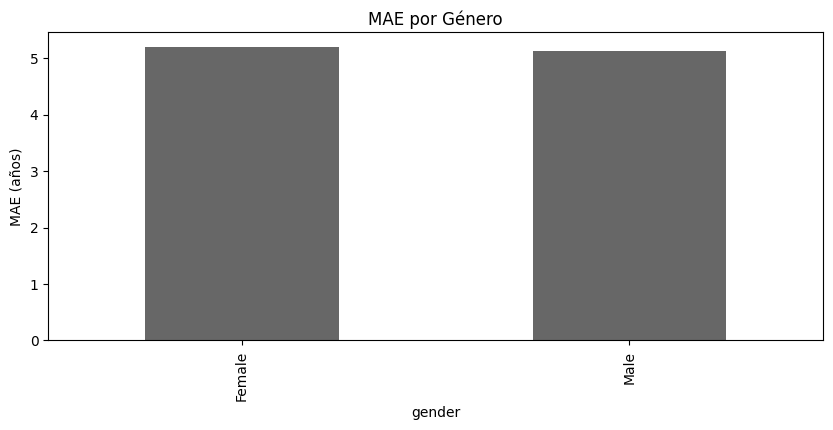

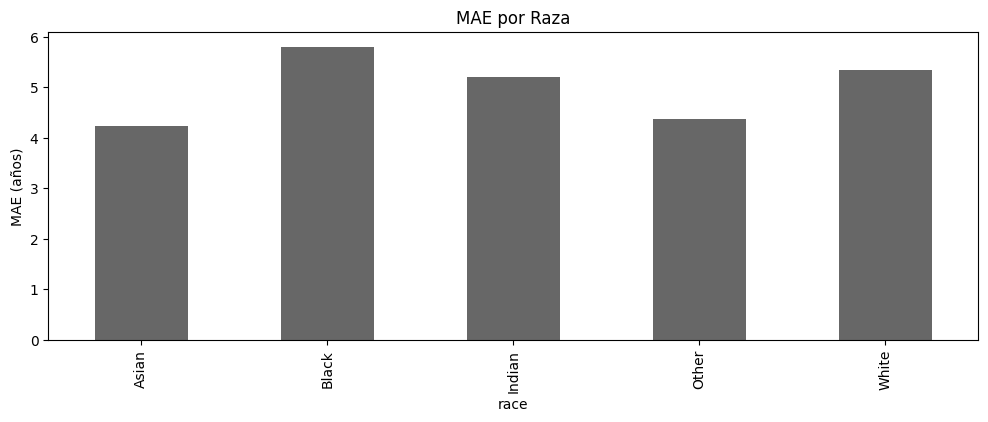

In [ ]:
plt.figure(figsize=(10,4))
mae_by_gender.plot(kind='bar', color='#414141', alpha = .8)
plt.ylabel("MAE (años)")
plt.title("MAE por Género")
plt.show()

plt.figure(figsize=(12,4))
mae_by_race.plot(kind='bar', color='#414141', alpha = .8)
plt.ylabel("MAE (años)")
plt.title("MAE por Raza")
plt.show()


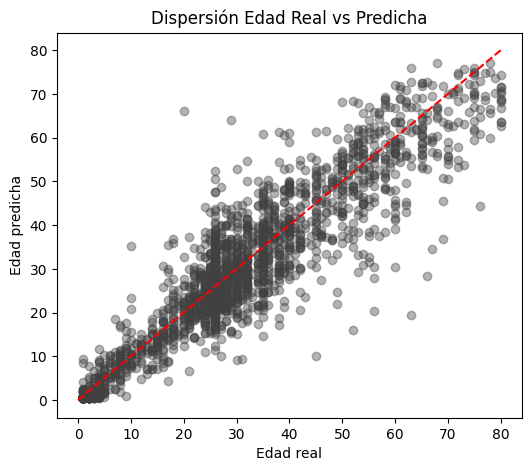

In [32]:
plt.figure(figsize=(6,5))
plt.scatter(test_df["true_age"], test_df["pred_age"], alpha=0.4, color = '#414141')
plt.xlabel("Edad real")
plt.ylabel("Edad predicha")
plt.title("Dispersión Edad Real vs Predicha")
plt.plot([0,80],[0,80],"r--")  # línea perfecta
plt.show()
